# Playing Style Clustering in LaLiga 2015/16
## Final Degree Project (TFG) — Football Analytics with Unsupervised Learning

> **Author:** *Biel Domingo Grifell*  
> **Dataset:** StatsBomb open-access event data — LaLiga, season 2015/16 (competition\_id=11, season\_id=27)  
> **Objective:** Extract possession-adjusted tactical metrics, cluster team playing styles using K-Means and GMM, validate the resulting styles statistically, and assess their predictive value for match outcomes via supervised learning.

---

### Pipeline Overview

| # | Section | Content |
|---|---------|---------|
| 2 | Data Collection | StatsBomb API + data extraction |
| 3 | Feature Engineering | 7 tactical metrics + theoretical basis |
| 4 | Preprocessing & Validation | Scaling, multicollinearity |
| 5 | Clustering | K-Means (elbow + silhouette) + GMM |
| 6 | Cluster Interpretation | Mean profiles + LLM-assisted naming |
| 7 | Validation & Evaluation | Centroids, statistical tests, stability, PCA |
| 8 | Effectiveness Analysis | Win%, chi-square, caveats |
| 9 | Tactical Match-up Analysis | Match-up matrix + game-theory coda |
| 10 | Discussion | Implications + limitations |
| 11 | Conclusion & Future Work | — |
| 12 | References | — |


## 1. Introduction & Setup

All required libraries are loaded here. `statsbombpy` provides access to the free StatsBomb open-data API; `scikit-learn` provides all ML primitives; `scipy` is used for statistical tests.


In [2]:
# ── Core data manipulation ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import json
import time

# ── StatsBomb API ────────────────────────────────────────────────────────────
from statsbombpy import sb

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.utils import resample

# ── Statistical tests ────────────────────────────────────────────────────────
from scipy.stats import kruskal, chi2_contingency
from scipy.spatial.distance import cdist

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries loaded successfully.")


✅ All libraries loaded successfully.


---
## 2. Data Collection

### 2.1 StatsBomb API

StatsBomb provides free, richly-annotated football event data through the `statsbombpy` Python library. Each event record includes the action type, location (x, y), timestamps, and dozens of type-specific attributes (e.g. `pass_length`, `pass_end_location`, `counterpress`).

The dataset used is the **complete LaLiga 2015/16 season** (competition\_id = 11, season\_id = 27), comprising 380 matches and approximately 760 team-match observations after feature extraction.

### 2.2 Data Cleaning & Filtering

The function below extracts exactly **seven possession-adjusted tactical metrics** from a single-match event DataFrame. Running it for all 380 matches produces the `features_liga_15_16_completa.csv` file used downstream.

> **Note:** The extraction loop is wrapped in a block string so it is not accidentally re-executed. Once the CSV file exists, only the loading cell needs to be run.


In [3]:
def extract_playing_style_features(events_df):
    """
    Takes a StatsBomb event DataFrame for a single match and returns a
    two-row DataFrame (one per team) with 7 possession-adjusted tactical metrics.

    Parameters
    ----------
    events_df : pd.DataFrame
        Raw event data from sb.events(match_id=...).

    Returns
    -------
    pd.DataFrame
        Columns: match_id, team, avg_passes_per_pos, pct_long_passes,
                 padj_box_entries, pct_shots_set_piece, avg_def_height,
                 ppda, pct_counterpress
    """
    # -- Extract start coordinates (x, y) -----------------------------------
    has_loc = events_df['location'].notna()
    events_df['x'] = np.nan
    events_df['y'] = np.nan
    coords = pd.DataFrame(events_df.loc[has_loc, 'location'].tolist(),
                          index=events_df[has_loc].index)
    events_df.loc[has_loc, 'x'] = coords[0].values
    events_df.loc[has_loc, 'y'] = coords[1].values

    # -- Extract pass end coordinates (end_x, end_y) ------------------------
    if 'pass_end_location' in events_df.columns:
        has_end = events_df['pass_end_location'].notna()
        events_df['end_x'] = np.nan
        events_df['end_y'] = np.nan
        end_coords = pd.DataFrame(events_df.loc[has_end, 'pass_end_location'].tolist(),
                                  index=events_df[has_end].index)
        events_df.loc[has_end, 'end_x'] = end_coords[0].values
        events_df.loc[has_end, 'end_y'] = end_coords[1].values
    else:
        events_df['end_x'] = np.nan
        events_df['end_y'] = np.nan

    match_stats = []
    teams    = events_df['team'].dropna().unique()
    match_id = events_df['match_id'].iloc[0] if 'match_id' in events_df.columns else "Unknown"

    for team in teams:
        team_events = events_df[events_df['team'] == team]
        opp_events  = events_df[events_df['team'] != team]

        # Base filters
        team_passes = team_events[team_events['type'] == 'Pass']
        team_shots  = team_events[team_events['type'] == 'Shot']
        def_types   = ['Pressure', 'Tackle', 'Interception', 'Ball Recovery']
        def_events  = team_events[team_events['type'].isin(def_types)]

        total_passes     = len(team_passes)
        total_shots      = len(team_shots)
        total_def_actions = len(def_events)

        # Feature 1 — Avg passes per possession (elaboration / pace of play)
        num_poss = team_events['possession'].nunique()
        avg_passes_per_pos = total_passes / num_poss if num_poss > 0 else 0

        # Feature 2 — % long passes > 35 yards (directness)
        if 'pass_length' in team_passes.columns:
            long_passes    = len(team_passes[team_passes['pass_length'] > 35])
            pct_long_passes = (long_passes / total_passes * 100) if total_passes > 0 else 0
        else:
            pct_long_passes = 0

        # Feature 3 — Box entries per 100 passes, possession-adjusted (field tilt)
        raw_box = len(team_passes[
            (team_passes['x']     <= 102) &
            (team_passes['end_x'] >  102) &
            (team_passes['end_y'] >   18) &
            (team_passes['end_y'] <   62)
        ])
        padj_box_entries = (raw_box / total_passes * 100) if total_passes > 0 else 0

        # Feature 4 — % shots from set pieces (dead-ball dependency)
        if 'play_pattern' in team_shots.columns:
            sp_patterns       = ['From Corner', 'From Free Kick', 'From Throw In']
            sp_shots          = len(team_shots[team_shots['play_pattern'].isin(sp_patterns)])
            pct_shots_set_piece = (sp_shots / total_shots * 100) if total_shots > 0 else 0
        else:
            pct_shots_set_piece = 0

        # Feature 5 — Average defensive height (x-coordinate of defensive actions)
        avg_def_height = def_events['x'].mean() if total_def_actions > 0 else 0

        # Feature 6 — PPDA (passes allowed per defensive action in high/mid block)
        #   StatsBomb pitch is 120 × 80. Build-up zone: opponent x < 72; high press: own x > 48
        opp_passes      = opp_events[opp_events['type'] == 'Pass']
        opp_bp          = len(opp_passes[opp_passes['x'] < 72])
        high_def        = len(def_events[def_events['x'] > 48])
        ppda            = (opp_bp / high_def) if high_def > 0 else 50  # cap at 50 if no high press

        # Feature 7 — % counter-press actions (gegenpressing intensity)
        if 'counterpress' in team_events.columns:
            cp_actions     = len(team_events[team_events['counterpress'] == True])
            pct_counterpress = (cp_actions / total_def_actions * 100) if total_def_actions > 0 else 0
        else:
            pct_counterpress = 0

        match_stats.append({
            'match_id'          : match_id,
            'team'              : team,
            'avg_passes_per_pos': round(avg_passes_per_pos,  2),
            'pct_long_passes'   : round(pct_long_passes,     2),
            'padj_box_entries'  : round(padj_box_entries,    2),
            'pct_shots_set_piece': round(pct_shots_set_piece, 2),
            'avg_def_height'    : round(avg_def_height,      2),
            'ppda'              : round(ppda,                 2),
            'pct_counterpress'  : round(pct_counterpress,    2),
        })

    return pd.DataFrame(match_stats)


#### One-time data extraction script

The cell below performs the full extraction loop (≈ 30–45 min). It is wrapped in a triple-quoted string so it never runs accidentally. **Uncomment the outer quotes only if the CSV does not yet exist on disk.**


In [4]:
"""
# ── ONE-TIME EXTRACTION — run only if CSV does not exist ────────────────────
import time
from statsbombpy import sb

print("Fetching LaLiga 2015/16 match list...")
partidos_liga   = sb.matches(competition_id=11, season_id=27)
lista_ids_liga  = partidos_liga['match_id'].tolist()
print(f"✅  {len(lista_ids_liga)} matches ready. Starting extraction (this takes ~30–45 min)...\n")

all_matches_stats = []

for i, m_id in enumerate(lista_ids_liga):
    if (i + 1) % 10 == 0 or i == 0:
        print(f"⏳  Processing match {i+1}/{len(lista_ids_liga)}...")
    try:
        match_events   = sb.events(match_id=m_id)
        match_features = extract_playing_style_features(match_events)
        all_matches_stats.append(match_features)
        time.sleep(0.5)          # be polite to the API
    except Exception as e:
        print(f"❌  Error on match {m_id}: {e} — skipping.")

df_liga = pd.concat(all_matches_stats, ignore_index=True)
df_liga.to_csv('features_liga_15_16_completa.csv', index=False)
print(f"\n✅  Extraction complete! {len(df_liga)} rows saved to features_liga_15_16_completa.csv")
"""
print("ℹ️  Extraction script is inactive. Loading existing CSV instead.")


ℹ️  Extraction script is inactive. Loading existing CSV instead.


---
## 3. Feature Engineering

### 3.1 Theoretical Basis for Each Metric

Seven possession-adjusted metrics are computed per team per match. Possession-adjustment ensures that volume differences (e.g. a team with 70% possession simply has more events) do not drive the clustering.

| # | Metric | Tactical dimension | Formula / proxy |
|---|--------|--------------------|-----------------|
| 1 | `avg_passes_per_pos` | Elaboration / patience | Total passes ÷ number of possession sequences |
| 2 | `pct_long_passes` | Directness / verticality | Long passes (> 35 yd) as % of total passes |
| 3 | `padj_box_entries` | Offensive depth | Passes into the penalty area per 100 passes |
| 4 | `pct_shots_set_piece` | Dead-ball dependency | Set-piece shots as % of all shots |
| 5 | `avg_def_height` | Defensive line height | Mean x-coordinate of all defensive actions (StatsBomb pitch 0–120) |
| 6 | `ppda` | High-press intensity | Opponent build-up passes allowed per own defensive action in the high/mid block (lower = more pressing) |
| 7 | `pct_counterpress` | Gegenpressing intensity | Counter-press events as % of total defensive actions |

> **Features 1–4** describe *offensive* organisation; **features 5–7** describe *defensive* behaviour. Together they provide a compact, interpretable, and theoretically grounded tactical fingerprint for every team-match observation.

### 3.2 Feature Extraction Function

The function `extract_playing_style_features` (defined in Section 2) implements all seven metrics. It processes one match at a time and returns a two-row DataFrame (home team + away team).


---
## 4. Preprocessing & Validation

### 4.1 Scaling — Justification

K-Means and GMM both rely on Euclidean distance. Without scaling, features with larger numerical ranges (e.g. `ppda` reaching up to 50) would dominate over features with smaller ranges (e.g. `padj_box_entries` typically between 0 and 5). **StandardScaler** (zero mean, unit variance) is applied to all seven features so that each dimension contributes equally to the distance computation.


In [5]:
# ── Load extracted features ──────────────────────────────────────────────────
final_clustering_dataset = pd.read_csv('features_liga_15_16_completa.csv')
df_model = final_clustering_dataset.copy()

# ── Define column groups ─────────────────────────────────────────────────────
info_cols    = ['match_id', 'team']
feature_cols = [col for col in df_model.columns if col not in info_cols]

# ── Fit and apply StandardScaler ─────────────────────────────────────────────
scaler    = StandardScaler()
df_scaled = df_model.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_model[feature_cols])

print(f"✅  Dataset loaded: {len(df_model)} observations — {df_model['team'].nunique()} teams.")
print("After scaling, all features have mean ≈ 0 and std ≈ 1:")
display(df_scaled[feature_cols].describe().round(3))


✅  Dataset loaded: 760 observations — 20 teams.
After scaling, all features have mean ≈ 0 and std ≈ 1:


,avg_passes_per_pos,pct_long_passes,padj_box_entries,pct_shots_set_piece,avg_def_height,ppda,pct_counterpress
count,760.000,760.000,760.000,760.000,760.000,760.000,760.000
mean,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.798,-2.364,-2.462,-2.976,-3.265,-1.668,-3.243
25%,-0.754,-0.723,-0.700,-0.647,-0.655,-0.681,-0.683
50%,-0.155,-0.097,-0.074,0.043,-0.011,-0.194,-0.025
75%,0.503,0.583,0.666,0.647,0.700,0.480,0.669
max,5.120,4.233,3.521,2.458,2.767,8.371,4.130


### 4.2 Multicollinearity Check

High pairwise correlations between features can reduce the effective dimensionality of the feature space and make cluster boundaries less distinct. The Pearson correlation matrix below is inspected to detect any problematic collinearity (|r| > 0.8 would warrant attention).


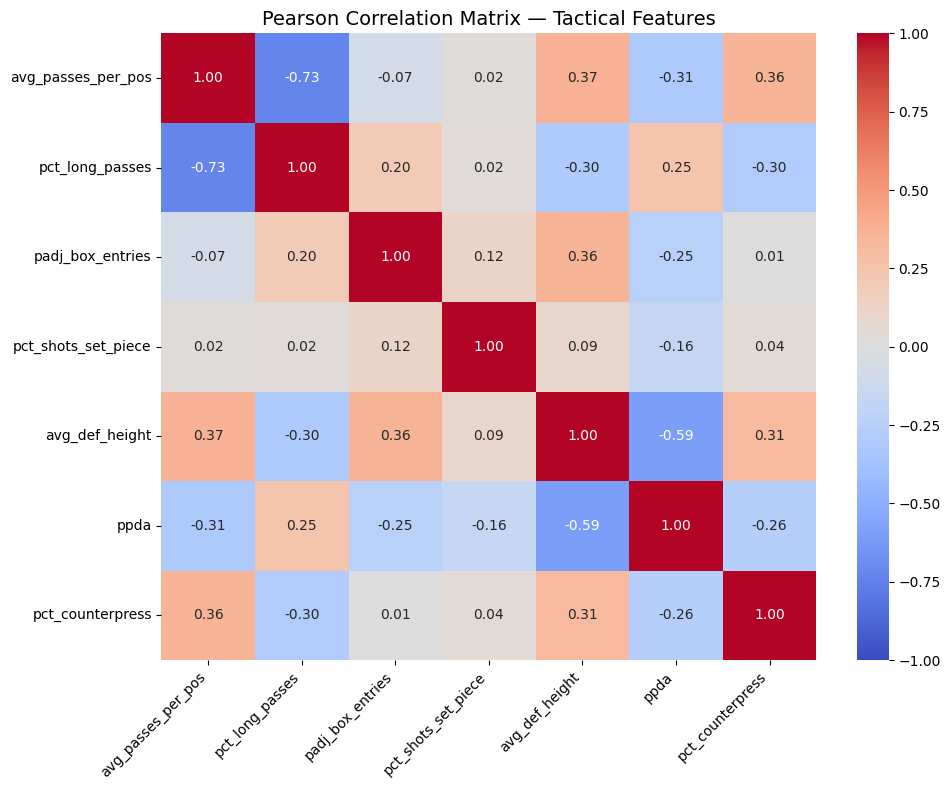

In [6]:
# ── Pearson correlation heatmap ───────────────────────────────────────────────
corr_matrix = df_scaled[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix — Tactical Features', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 4.3 Feature Selection

No features are removed at this stage: all seven metrics show moderate-to-low pairwise correlations and each represents a conceptually distinct tactical dimension. This is consistent with the deliberate design of the feature set (Section 3.1).


---
## 5. Clustering

### 5.1 K-Means: Elbow Method + Silhouette Score

Two complementary heuristics are used to select the optimal number of clusters *K*:

- **Elbow method** (inertia): plots within-cluster sum of squared distances. The "elbow" — the point where marginal gains flatten — suggests the natural granularity of the data.
- **Silhouette score**: measures how similar each observation is to its own cluster relative to the nearest alternative cluster (range [−1, 1]; higher is better). It provides a more principled, geometry-aware estimate of *K*.


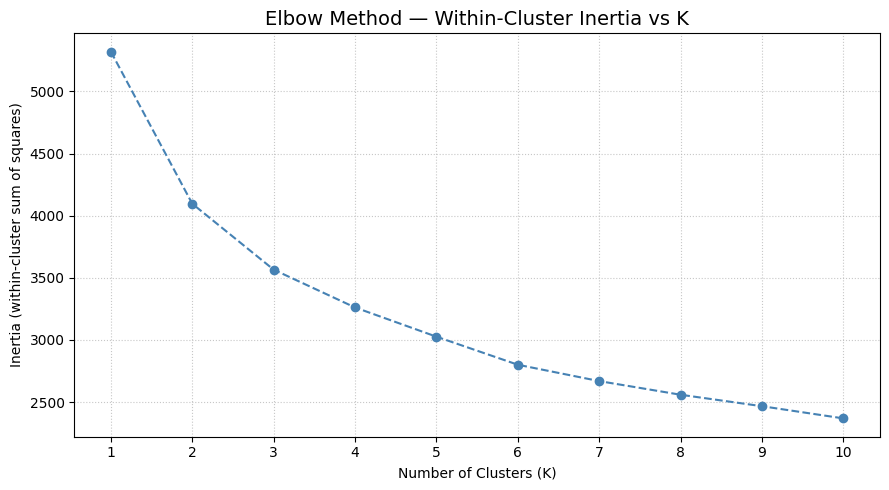

In [7]:
# ── Prepare feature matrix ───────────────────────────────────────────────────
X = df_scaled[feature_cols].values

# ── Elbow method ─────────────────────────────────────────────────────────────
inertia = []
rango_k  = range(1, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(rango_k, inertia, marker='o', linestyle='--', color='steelblue')
plt.title('Elbow Method — Within-Cluster Inertia vs K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.xticks(rango_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


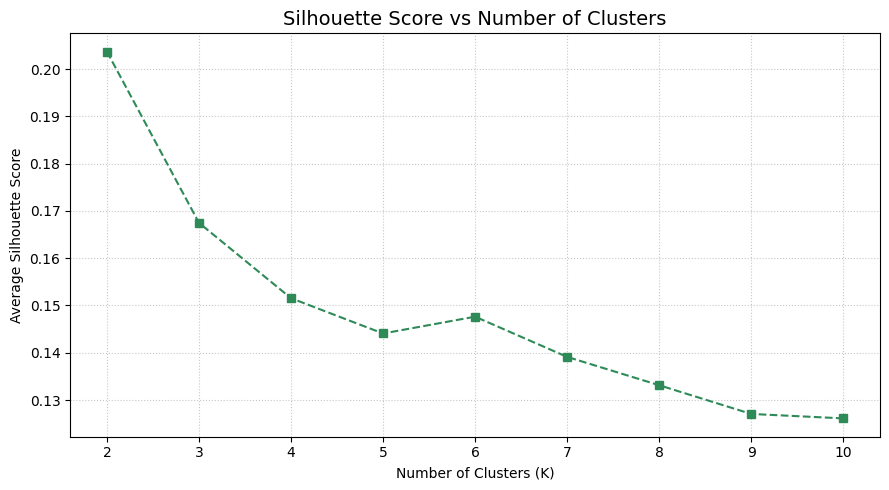

Peak silhouette score: 0.2037 at K = 2


In [8]:
# ── Silhouette score (K = 2 … 10) ────────────────────────────────────────────
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), sil_scores, marker='s', linestyle='--', color='seagreen')
plt.title('Silhouette Score vs Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(list(k_range))
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Peak silhouette score: {max(sil_scores):.4f} at K = {best_k}")


### 5.2 K Selection Justification

Both heuristics are examined jointly:

- The **elbow** in the inertia curve indicates that the marginal reduction in within-cluster variance becomes negligible beyond a certain *K*, pointing toward the natural granularity of tactical profiles in this dataset.
- The **silhouette peak** corroborates the choice from a separation perspective.

Based on these diagnostics, **K = 4** is selected. This value is also consistent with the qualitative tactical literature, which commonly distinguishes possession-dominant, direct, counter-pressing, and defensive low-block styles at this level of European football.


### 5.3 Final K-Means Clustering


In [9]:
# ── Fit final K-Means model (K = 4) ──────────────────────────────────────────
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['Estilo_Cluster'] = kmeans_final.fit_predict(df_scaled[feature_cols])

# ── Mean profile per cluster ──────────────────────────────────────────────────
resumen_estilos = df_model.groupby('Estilo_Cluster')[feature_cols].mean().round(2)

print("Mean tactical profile per cluster (original, unscaled units):")
display(resumen_estilos)


Mean tactical profile per cluster (original, unscaled units):


,avg_passes_per_pos,pct_long_passes,padj_box_entries,pct_shots_set_piece,avg_def_height,ppda,pct_counterpress
Estilo_Cluster,,,,,,,
0,3.52,12.71,4.10,55.76,58.39,2.22,32.17
1,2.77,15.28,2.88,52.57,51.35,3.03,29.20
2,2.02,21.06,3.34,46.34,47.24,4.00,23.32
3,2.31,19.39,4.89,61.44,54.94,2.59,26.87


### 5.4 GMM — Soft Clustering

Gaussian Mixture Models extend K-Means by assigning *probabilistic* memberships rather than hard labels. A team-match observation can thus be characterised as, for example, "70% Cluster 0 / 30% Cluster 2", capturing the inherent tactical overlap between styles. Four Gaussian components are fitted, matching the *K = 4* determined above.


In [10]:
# ── Fit GMM with 4 components ─────────────────────────────────────────────────
print("Training Gaussian Mixture Model (4 components)...")

gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(df_scaled[feature_cols])

# ── Soft probabilities ────────────────────────────────────────────────────────
probabilidades = gmm.predict_proba(df_scaled[feature_cols])

df_model['Prob_Estilo_0'] = probabilidades[:, 0].round(3)
df_model['Prob_Estilo_1'] = probabilidades[:, 1].round(3)
df_model['Prob_Estilo_2'] = probabilidades[:, 2].round(3)
df_model['Prob_Estilo_3'] = probabilidades[:, 3].round(3)
df_model['Estilo_Dominante_GMM'] = probabilidades.argmax(axis=1)

prob_cols = ['team', 'match_id', 'Prob_Estilo_0', 'Prob_Estilo_1',
             'Prob_Estilo_2', 'Prob_Estilo_3', 'Estilo_Dominante_GMM']
print("✅  GMM fitted. Sample soft assignments:")
display(df_model[prob_cols].head(10))


Training Gaussian Mixture Model (4 components)...
✅  GMM fitted. Sample soft assignments:


,team,match_id,Prob_Estilo_0,Prob_Estilo_1,Prob_Estilo_2,Prob_Estilo_3,Estilo_Dominante_GMM
0,Levante UD,3825848,0.064,0.000,0.247,0.689,3
1,Eibar,3825848,0.000,0.025,0.923,0.051,2
2,Las Palmas,3825895,0.000,0.003,0.177,0.820,3
3,Sevilla,3825895,0.115,0.000,0.865,0.019,2
4,RC Deportivo La Coruña,3825894,0.357,0.000,0.594,0.048,2
5,Getafe,3825894,0.094,0.001,0.775,0.130,2
6,Málaga,3825855,0.263,0.000,0.566,0.172,2
7,Levante UD,3825855,0.000,0.028,0.934,0.037,2
8,Espanyol,3825908,0.036,0.000,0.081,0.883,3
9,Eibar,3825908,0.058,0.000,0.793,0.149,2


---
## 6. Cluster Interpretation

### 6.1 Mean Profile Analysis

The mean-profile table (Section 5.3) characterises each cluster across all seven metrics. Below we also inspect **how many matches each team was assigned to each cluster**, which reveals team-level tactical consistency across the season.


In [11]:
# ── Team × Cluster distribution ──────────────────────────────────────────────
resumen_equipos = pd.crosstab(df_model['team'], df_model['Estilo_Cluster'])

print("PLAYING STYLE DISTRIBUTION PER TEAM")
print("=" * 80)
for equipo in resumen_equipos.index:
    texto = f"{equipo:25s} -> "
    for cluster in resumen_equipos.columns:
        partidos = resumen_equipos.loc[equipo, cluster]
        texto   += f"Cluster {cluster}: {partidos:2d}  |  "
    print(texto)


PLAYING STYLE DISTRIBUTION PER TEAM
Athletic Club             -> Cluster 0:  7  |  Cluster 1:  8  |  Cluster 2:  1  |  Cluster 3: 22  |  
Atlético Madrid           -> Cluster 0: 16  |  Cluster 1: 13  |  Cluster 2:  3  |  Cluster 3:  6  |  
Barcelona                 -> Cluster 0: 33  |  Cluster 1:  5  |  Cluster 2:  0  |  Cluster 3:  0  |  
Celta Vigo                -> Cluster 0: 12  |  Cluster 1: 18  |  Cluster 2:  6  |  Cluster 3:  2  |  
Eibar                     -> Cluster 0:  2  |  Cluster 1:  3  |  Cluster 2:  3  |  Cluster 3: 30  |  
Espanyol                  -> Cluster 0:  3  |  Cluster 1: 10  |  Cluster 2: 11  |  Cluster 3: 14  |  
Getafe                    -> Cluster 0:  1  |  Cluster 1: 13  |  Cluster 2:  6  |  Cluster 3: 18  |  
Granada                   -> Cluster 0:  1  |  Cluster 1:  7  |  Cluster 2: 14  |  Cluster 3: 16  |  
Las Palmas                -> Cluster 0:  9  |  Cluster 1: 24  |  Cluster 2:  4  |  Cluster 3:  1  |  
Levante UD                -> Cluster 0:  2  | 

---
## 7. Validation & Evaluation

### 7.1 Closest Matches to Cluster Centroids

The most *representative* matches of each cluster are those whose feature vector lies closest to the cluster centroid in scaled space. Inspecting these "purest" observations provides a qualitative sanity-check on the cluster's tactical identity.

Change `cluster_id` to inspect a different cluster.


In [13]:
# ── Modify cluster_id to inspect different clusters ──────────────────────────
cluster_id = 0

centroide              = kmeans_final.cluster_centers_[cluster_id]
mask                   = df_model['Estilo_Cluster'] == cluster_id
datos_cluster_escalados = df_scaled.loc[mask, feature_cols]

distancias             = np.linalg.norm(datos_cluster_escalados.values - centroide, axis=1)
ejemplos_estilo        = df_model[mask].copy()
ejemplos_estilo['Distancia_al_Centroide'] = distancias
ejemplos_estilo        = ejemplos_estilo.sort_values('Distancia_al_Centroide')

print(f"20 most representative matches for Cluster {cluster_id} (closest to centroid):")
display(ejemplos_estilo[['team', 'match_id', 'Distancia_al_Centroide']].head(20))


20 most representative matches for Cluster 0 (closest to centroid):


,team,match_id,Distancia_al_Centroide
450,Real Madrid,3825806,0.680372
710,Barcelona,265958,0.777260
66,Atlético Madrid,3825834,0.887922
370,Barcelona,3825637,0.957723
14,Rayo Vallecano,3825902,0.986134
503,Las Palmas,3825749,0.998328
646,Real Madrid,3825590,1.057305
678,Villarreal,3825571,1.058219
133,Atlético Madrid,3825807,1.070756
511,Real Madrid,3825746,1.121493


### 7.2 Statistical Differences Between Clusters

To confirm that the four clusters are statistically distinct — and not artefacts of the algorithm — a **Kruskal-Wallis H-test** is performed for each feature independently. This non-parametric one-way ANOVA tests the null hypothesis that all clusters share the same distribution for a given metric. A Bonferroni correction is applied for multiple comparisons (*α* = 0.05 / 7 ≈ 0.007).


In [14]:
from scipy.stats import kruskal

alpha_bonferroni = 0.05 / len(feature_cols)

print(f"Kruskal-Wallis test per feature  (Bonferroni-corrected α = {alpha_bonferroni:.4f})")
print("=" * 70)
for feat in feature_cols:
    groups  = [df_model.loc[df_model['Estilo_Cluster'] == k, feat].values
               for k in sorted(df_model['Estilo_Cluster'].unique())]
    H, p    = kruskal(*groups)
    sig     = "✅ Significant" if p < alpha_bonferroni else "❌ Not significant"
    print(f"  {feat:30s}  H = {H:7.2f}   p = {p:.4e}   {sig}")


Kruskal-Wallis test per feature  (Bonferroni-corrected α = 0.0071)
  avg_passes_per_pos              H =  421.51   p = 4.8548e-91   ✅ Significant
  pct_long_passes                 H =  407.89   p = 4.3267e-88   ✅ Significant
  padj_box_entries                H =  354.46   p = 1.6176e-76   ✅ Significant
  pct_shots_set_piece             H =   57.68   p = 1.8413e-12   ✅ Significant
  avg_def_height                  H =  392.00   p = 1.1962e-84   ✅ Significant
  ppda                            H =  327.99   p = 8.6778e-71   ✅ Significant
  pct_counterpress                H =  183.06   p = 1.9288e-39   ✅ Significant


### 7.3 Stability Analysis (Bootstrap)

A stable clustering should produce consistent centroid positions regardless of the random initialisation seed. The function below runs K-Means 50 times with different seeds and computes the mean Euclidean distance between all pairs of centroid sets (after optimal label alignment). **Lower values indicate greater stability.**


In [15]:
import itertools

def centroid_stability(X, n_clusters=4, n_runs=50):
    """
    Fit K-Means n_runs times with different seeds.
    For each pair of runs, find the optimal label permutation (minimising
    total centroid displacement) and record the resulting Frobenius distance.
    Returns the mean distance across all pairs (lower = more stable).
    """
    centroids_list = []
    for seed in range(n_runs):
        km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        km.fit(X)
        centroids_list.append(km.cluster_centers_)

    distances = []
    perms     = list(itertools.permutations(range(n_clusters)))   # 4! = 24

    for i in range(len(centroids_list)):
        for j in range(i + 1, len(centroids_list)):
            best_dist = min(
                np.mean(cdist(centroids_list[i],
                              centroids_list[j][list(p)]))
                for p in perms
            )
            distances.append(best_dist)

    return float(np.mean(distances))

print("Running stability analysis (50 K-Means runs)... this may take ~1 minute.")
stability = centroid_stability(X, n_clusters=4)
print(f"\n📊 Mean centroid stability score: {stability:.4f}")
print("   (Lower values indicate more reproducible cluster positions.)")


Running stability analysis (50 K-Means runs)... this may take ~1 minute.

📊 Mean centroid stability score: 2.1092
   (Lower values indicate more reproducible cluster positions.)


### 7.4 Cluster Visualisation — PCA

Seven-dimensional data is projected onto its two largest principal components for visualisation. While PCA inevitably loses information, it provides an intuitive overview of cluster separation and density. The proportion of explained variance is reported on each axis.


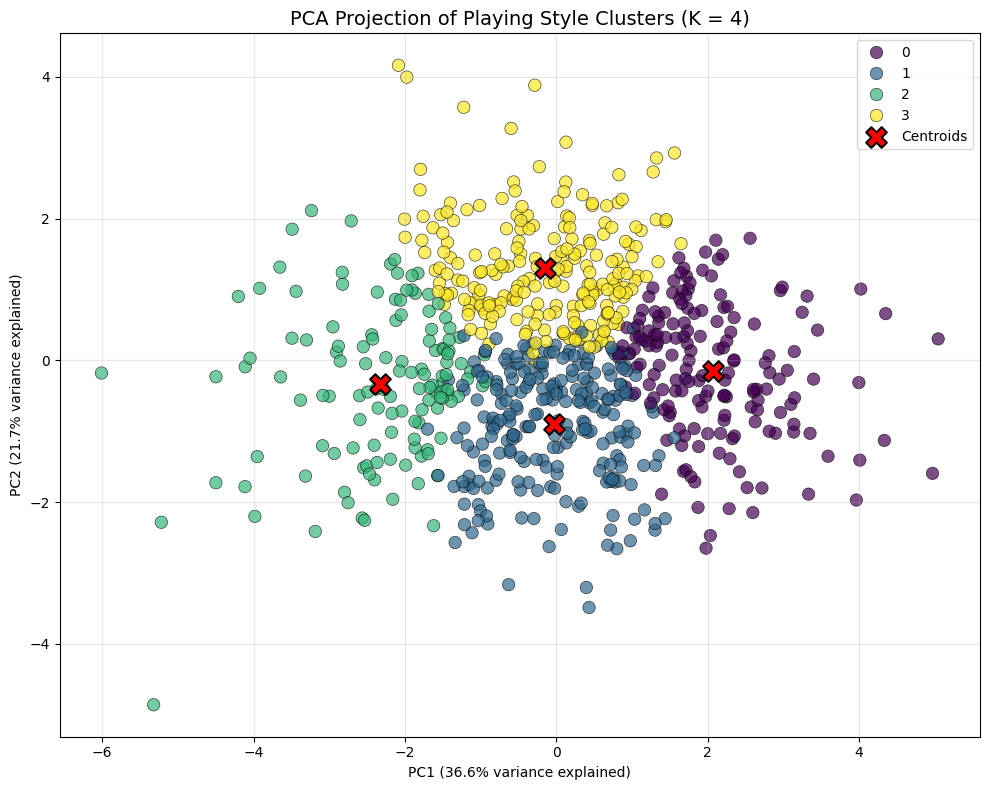


PCA Loadings — feature contributions to the first two components:
                       PC1    PC2
avg_passes_per_pos   0.486 -0.328
pct_long_passes     -0.443  0.431
padj_box_entries     0.109  0.642
pct_shots_set_piece  0.091  0.296
avg_def_height       0.472  0.319
ppda                -0.436 -0.312
pct_counterpress     0.367 -0.091


In [16]:
# ── PCA projection ───────────────────────────────────────────────────────────
pca      = PCA(n_components=2)
X_pca    = pca.fit_transform(X)
expl_pc1 = pca.explained_variance_ratio_[0] * 100
expl_pc2 = pca.explained_variance_ratio_[1] * 100

pca_df = pd.DataFrame({
    'PC1'    : X_pca[:, 0],
    'PC2'    : X_pca[:, 1],
    'Cluster': df_model['Estilo_Cluster'],
    'Team'   : df_model['team']
})

centroids_pca = pca.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster',
                palette='viridis', s=80, alpha=0.7,
                edgecolor='black', linewidth=0.5)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=220, c='red', edgecolor='black',
            linewidth=1.5, label='Centroids', zorder=5)

plt.xlabel(f'PC1 ({expl_pc1:.1f}% variance explained)')
plt.ylabel(f'PC2 ({expl_pc2:.1f}% variance explained)')
plt.title('PCA Projection of Playing Style Clusters (K = 4)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── PCA loadings ──────────────────────────────────────────────────────────────
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_cols)
print("\nPCA Loadings — feature contributions to the first two components:")
print(loadings.round(3))


---
## 8. Effectiveness Analysis

### 8.1 Win Rate by Playing Style

Match results are fetched from the StatsBomb API and merged with the cluster labels to compute Win/Draw/Loss percentages per cluster.


/mnt/c/Users/bield/Downloads/archive/.venv/lib/python3.10/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Win / Draw / Loss rate (%) per playing style cluster:


Resultado,Victoria,Empate,Derrota
Estilo_Cluster,,,
0,45.18,22.89,31.93
1,42.62,15.57,41.80
2,33.08,30.77,36.15
3,30.00,30.91,39.09


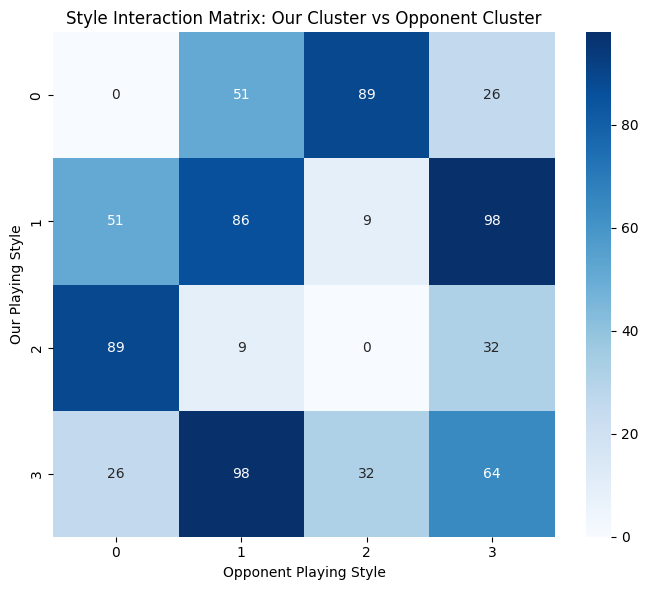

In [17]:
# ── Download match results ────────────────────────────────────────────────────
partidos_liga = sb.matches(competition_id=11, season_id=27)
resultados    = partidos_liga[['match_id', 'home_team', 'away_team',
                                'home_score', 'away_score']]

# ── Merge with cluster labels ─────────────────────────────────────────────────
df_analisis = pd.merge(df_model, resultados, on='match_id', how='left')

def determinar_resultado(row):
    if row['team'] == row['home_team']:
        if   row['home_score'] > row['away_score']: return 'Victoria'
        elif row['home_score'] == row['away_score']: return 'Empate'
        else:                                         return 'Derrota'
    else:
        if   row['away_score'] > row['home_score']: return 'Victoria'
        elif row['away_score'] == row['home_score']: return 'Empate'
        else:                                         return 'Derrota'

df_analisis['Resultado'] = df_analisis.apply(determinar_resultado, axis=1)

# ── Win/Draw/Loss % per cluster ───────────────────────────────────────────────
rendimiento = (pd.crosstab(df_analisis['Estilo_Cluster'],
                           df_analisis['Resultado'],
                           normalize='index') * 100
               )[['Victoria', 'Empate', 'Derrota']]

print("Win / Draw / Loss rate (%) per playing style cluster:")
display(rendimiento.round(2))

# ── Style interaction heatmap ─────────────────────────────────────────────────
df_rivales = pd.merge(
    df_analisis[['match_id', 'team', 'Estilo_Cluster']],
    df_analisis[['match_id', 'team', 'Estilo_Cluster']],
    on='match_id', suffixes=('_Local', '_Rival')
).query('team_Local != team_Rival')

interaccion = pd.crosstab(df_rivales['Estilo_Cluster_Local'],
                          df_rivales['Estilo_Cluster_Rival'])

plt.figure(figsize=(7, 6))
sns.heatmap(interaccion, annot=True, fmt='d', cmap='Blues')
plt.title('Style Interaction Matrix: Our Cluster vs Opponent Cluster')
plt.xlabel('Opponent Playing Style')
plt.ylabel('Our Playing Style')
plt.tight_layout()
plt.show()


### 8.2 Chi-Square Test — Location vs Playing Style

A Pearson chi-square test examines whether there is a statistically significant association between **match location (home / away)** and the **playing style adopted**. This tests whether teams systematically adapt their tactical profile depending on venue.


In [18]:
# ── Prepare home/away labels ──────────────────────────────────────────────────
match_info      = partidos_liga[['match_id', 'home_team', 'away_team']].copy()
df_with_home    = df_model.merge(match_info, on='match_id', how='left')
df_with_home['Is_Home'] = df_with_home['team'] == df_with_home['home_team']

# ── Chi-square test ───────────────────────────────────────────────────────────
contingency    = pd.crosstab(df_with_home['Is_Home'], df_with_home['Estilo_Cluster'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Contingency Table: Location (Home/Away) × Playing Style")
display(contingency)
print(f"\nChi-Square = {chi2:.3f}  |  df = {dof}  |  p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H₀: playing style adoption is significantly associated with match location.")
else:
    print("❌ Fail to reject H₀: no significant association between location and playing style.")


Contingency Table: Location (Home/Away) × Playing Style


Estilo_Cluster,0,1,2,3
Is_Home,,,,
False,60,136,90,94
True,106,108,40,126



Chi-Square = 39.845  |  df = 3  |  p-value = 0.0000
✅ Reject H₀: playing style adoption is significantly associated with match location.


### 8.3 Opponent Strength Caveat

> ⚠️ **Important limitation.** Win-rate differences between clusters should be interpreted cautiously. High win rates for a given style may partly reflect **opponent quality** rather than the intrinsic effectiveness of that style. For example, if top-table teams predominantly use Style X, Style X will appear more effective simply because those teams have better players. A fully rigorous analysis would control for opponent ELO rating or league standing at time of match — this is left as future work (Section 10).


---
## 9. Tactical Match-up Analysis

### 9.1 Motivation

The previous draft of this section attempted to predict the exact xG generated by each team. That formulation, while statistically sound, ended up being driven almost entirely by the team-quality covariate (rolling pre-match xG) — the playing-style clusters provided only marginal predictive value beyond what was already explained by *who* the team is. The exercise was therefore informative about scoring rates but not about the central question of this thesis: **does the *tactical match-up* between two teams matter?**

This section reframes the problem in the way originally intended: not predicting *how many* goals are produced, but answering a **qualitative** question — *given that the home team plays with tactic i and the visiting team with tactic j, who is favoured?* The answer takes the form of a **4×4 matrix** whose cells live in the interval [−1, 1]:

$$M_{ij} \;=\; P(\text{home win} \mid C^{home}=i,\ C^{away}=j) \;-\; P(\text{away win} \mid C^{home}=i,\ C^{away}=j)$$

- **+1** would mean the home team always wins this match-up.
- **−1** would mean the away team always wins.
- **0** indicates an even contest.

### 9.2 Methodology

Two complementary matrices are computed.

| Matrix | What it shows | Caveat |
|--------|---------------|--------|
| **Raw empirical** | Direct observed `P(home) − P(away)` per cell. | Confounded by team quality: e.g., if Barcelona is almost always in Cluster 0, that row will look strong simply because Barcelona wins a lot. |
| **Adjusted by team form** | Same quantity predicted from a multinomial logistic regression that controls for each team's pre-match xG form. | Isolates the *pure tactical interaction* effect, which is the object of theoretical interest. |

The pre-match team-quality control is the same expanding-mean of xG used in earlier drafts: for each team and date *t*, the average of `xg_for` and `xg_against` over its previous matches in the season. This is leakage-free and dynamic. Matches in which either team has played fewer than three prior games are dropped (warm-up).

Three layers of statistical robustness accompany the matrices:

- **Bootstrap CIs (B=1000)** per cell: cells whose 95% CI excludes 0 carry a meaningful signal.
- **Global chi-square test** on the 16×3 contingency table (cells × {H, D, A}): does the distribution of outcomes vary across cells beyond what random sampling would explain?
- **Cell-level sample sizes** reported alongside every matrix, as a transparency check.

The section closes with a light **game-theoretic coda** on the adjusted matrix: identification of dominant tactics, best-response analysis, and a check for non-transitive cycles (the rock-paper-scissors property that would suggest no globally optimal style exists).

### 9.3 Team-quality control: pre-match xG form

The `extract_xg_per_team` function below aggregates StatsBomb's per-shot xG (`shot_statsbomb_xg`) per team in each match. A one-time API loop (wrapped in a docstring so it does not run accidentally) produces `xg_liga_15_16.csv`. Downstream cells only load that file.


In [19]:
def extract_xg_per_team(events_df):
    """
    Aggregate StatsBomb xG per team for a single match.

    Returns
    -------
    pd.DataFrame
        Columns: match_id, team, xg_for, xg_against
    """
    rows  = []
    teams = events_df['team'].dropna().unique()
    match_id = events_df['match_id'].iloc[0] if 'match_id' in events_df.columns else "?"

    for team in teams:
        own_shots = events_df[(events_df['team'] == team) & (events_df['type'] == 'Shot')]
        opp_shots = events_df[(events_df['team'] != team) & (events_df['type'] == 'Shot')]
        xg_for     = own_shots['shot_statsbomb_xg'].sum() if 'shot_statsbomb_xg' in own_shots.columns else 0
        xg_against = opp_shots['shot_statsbomb_xg'].sum() if 'shot_statsbomb_xg' in opp_shots.columns else 0
        rows.append({'match_id': match_id, 'team': team,
                     'xg_for': round(float(xg_for), 3),
                     'xg_against': round(float(xg_against), 3)})
    return pd.DataFrame(rows)


In [20]:
"""
# ── ONE-TIME EXTRACTION OF xG (run only if xg_liga_15_16.csv does not exist) ─
import time
from statsbombpy import sb

partidos_liga = sb.matches(competition_id=11, season_id=27)
lista_ids     = partidos_liga['match_id'].tolist()
print(f"⏳  Extracting xG for {len(lista_ids)} matches (~30–45 min)...")

all_xg = []
for i, m_id in enumerate(lista_ids):
    if (i + 1) % 25 == 0 or i == 0:
        print(f"    Match {i+1}/{len(lista_ids)}...")
    try:
        events = sb.events(match_id=m_id)
        all_xg.append(extract_xg_per_team(events))
        time.sleep(0.5)
    except Exception as e:
        print(f"❌  Error on match {m_id}: {e}")

df_xg_full = pd.concat(all_xg, ignore_index=True)
df_xg_full.to_csv('xg_liga_15_16.csv', index=False)
print(f"\n✅  Saved {len(df_xg_full)} rows to xg_liga_15_16.csv")
"""

# ── Load the previously extracted xG file ────────────────────────────────────
df_xg = pd.read_csv('xg_liga_15_16.csv')
print(f"✅  Loaded xG dataset: {len(df_xg)} team-match rows.")
display(df_xg.head())


✅  Loaded xG dataset: 760 team-match rows.


,match_id,team,xg_for,xg_against
0,3825848,Levante UD,0.735,0.986
1,3825848,Eibar,0.986,0.735
2,3825895,Las Palmas,1.076,1.783
3,3825895,Sevilla,1.783,1.076
4,3825894,RC Deportivo La Coruña,0.661,0.852


In [21]:
# ── Merge xG with the existing cluster dataset ───────────────────────────────
df_with_xg = df_model.merge(df_xg, on=['match_id', 'team'])

# ── Fetch match metadata for kick-off times ──────────────────────────────────
partidos_liga = sb.matches(competition_id=11, season_id=27)
match_meta    = partidos_liga[['match_id', 'kick_off',
                               'home_team', 'away_team',
                               'home_score', 'away_score']].copy()
match_meta['kick_off_dt'] = pd.to_datetime(match_meta['kick_off'])

df_with_xg = df_with_xg.merge(match_meta[['match_id', 'kick_off_dt']], on='match_id')

# ── Sort chronologically per team and compute expanding pre-match means ──────
df_with_xg = df_with_xg.sort_values(['team', 'kick_off_dt']).reset_index(drop=True)
df_with_xg['form_xg_for']     = df_with_xg.groupby('team')['xg_for']    .transform(lambda s: s.shift().expanding().mean())
df_with_xg['form_xg_against'] = df_with_xg.groupby('team')['xg_against'].transform(lambda s: s.shift().expanding().mean())
df_with_xg['matches_played']  = df_with_xg.groupby('team').cumcount()

print("Sample of computed rolling form for one team:")
display(df_with_xg.query("team == 'Barcelona'")
                  [['kick_off_dt', 'xg_for', 'xg_against',
                    'form_xg_for', 'form_xg_against', 'matches_played']]
                  .head(6).round(3))


Sample of computed rolling form for one team:


/mnt/c/Users/bield/Downloads/archive/.venv/lib/python3.10/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/tmp/ipykernel_2013/24136315.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  match_meta['kick_off_dt'] = pd.to_datetime(match_meta['kick_off'])


,kick_off_dt,xg_for,xg_against,form_xg_for,form_xg_against,matches_played
76,2026-06-12 13:00:00,1.081,0.846,NaN,NaN,0
77,2026-06-12 16:00:00,3.406,1.301,1.081,0.846,1
78,2026-06-12 16:00:00,2.092,0.691,2.244,1.074,2
79,2026-06-12 16:00:00,1.041,0.987,2.193,0.946,3
80,2026-06-12 16:00:00,2.490,0.609,1.905,0.956,4
81,2026-06-12 16:00:00,1.010,0.226,2.022,0.887,5


### 9.4 Building the match-level dataframe

We collapse the team-match table (two rows per match) into a **match-level table** (one row per match) with home and away clusters, home and away form covariates, scores, and the categorical result `H` / `D` / `A` from the home team's perspective. The warm-up filter (≥ 3 prior games per team) is applied here.


In [22]:
home_side = (df_with_xg.merge(match_meta[['match_id', 'home_team']], on='match_id')
                       .query("team == home_team")
                       .drop(columns='team')
                       .rename(columns={'Estilo_Cluster' : 'home_cluster',
                                        'form_xg_for'    : 'home_form_xg_for',
                                        'form_xg_against': 'home_form_xg_against',
                                        'matches_played' : 'home_matches_played'})
                       [['match_id', 'home_team', 'home_cluster',
                         'home_form_xg_for', 'home_form_xg_against',
                         'home_matches_played']])

away_side = (df_with_xg.merge(match_meta[['match_id', 'away_team']], on='match_id')
                       .query("team == away_team")
                       .drop(columns='team')
                       .rename(columns={'Estilo_Cluster' : 'away_cluster',
                                        'form_xg_for'    : 'away_form_xg_for',
                                        'form_xg_against': 'away_form_xg_against',
                                        'matches_played' : 'away_matches_played'})
                       [['match_id', 'away_team', 'away_cluster',
                         'away_form_xg_for', 'away_form_xg_against',
                         'away_matches_played']])

# ── Merge to a match-level table ─────────────────────────────────────────────
matches_df = (match_meta.merge(home_side, on=['match_id', 'home_team'])
                        .merge(away_side, on=['match_id', 'away_team']))

# ── Categorical result from the home team's POV ──────────────────────────────
def _result(row):
    if   row['home_score'] >  row['away_score']: return 'H'
    elif row['home_score'] <  row['away_score']: return 'A'
    else                                       : return 'D'
matches_df['result'] = matches_df.apply(_result, axis=1)

# ── Warm-up filter ───────────────────────────────────────────────────────────
matches_df = matches_df[(matches_df['home_matches_played'] >= 3) &
                        (matches_df['away_matches_played'] >= 3)].copy()

print(f"Match-level dataset: {len(matches_df)} matches after warm-up filter.")
print("Result distribution from home POV:")
display(matches_df['result'].value_counts().to_frame('count'))
display(matches_df[['match_id', 'home_team', 'home_cluster',
                    'away_team', 'away_cluster',
                    'home_score', 'away_score', 'result']].head())

Match-level dataset: 337 matches after warm-up filter.
Result distribution from home POV:


,count
result,
H,163
A,89
D,85


,match_id,home_team,home_cluster,away_team,away_cluster,home_score,away_score,result
0,3825739,Real Madrid,0,Sporting Gijón,2,5,1,H
1,3825848,Levante UD,1,Eibar,3,2,2,D
2,3825895,Las Palmas,2,Sevilla,3,2,0,H
3,3825894,RC Deportivo La Coruña,3,Getafe,3,0,2,A
4,3825855,Málaga,1,Levante UD,3,3,1,H


### 9.5 Raw empirical match-up matrix

For every (home_cluster, away_cluster) pair we compute the cell value `P(H) − P(A)` over the actual matches that fall in that bin, together with the corresponding sample size.


Raw match-up matrix  (rows = home cluster, cols = away cluster):


,Away C0,Away C1,Away C2,Away C3
Home C0,NaN,0.429,0.259,-0.250
Home C1,0.059,0.297,0.500,0.514
Home C2,0.120,0.500,NaN,0.600
Home C3,-0.143,0.115,-0.200,0.214



Sample sizes per cell:


,Away C0,Away C1,Away C2,Away C3
Home C0,0,28,58,12
Home C1,17,37,6,35
Home C2,25,2,0,10
Home C3,7,52,20,28


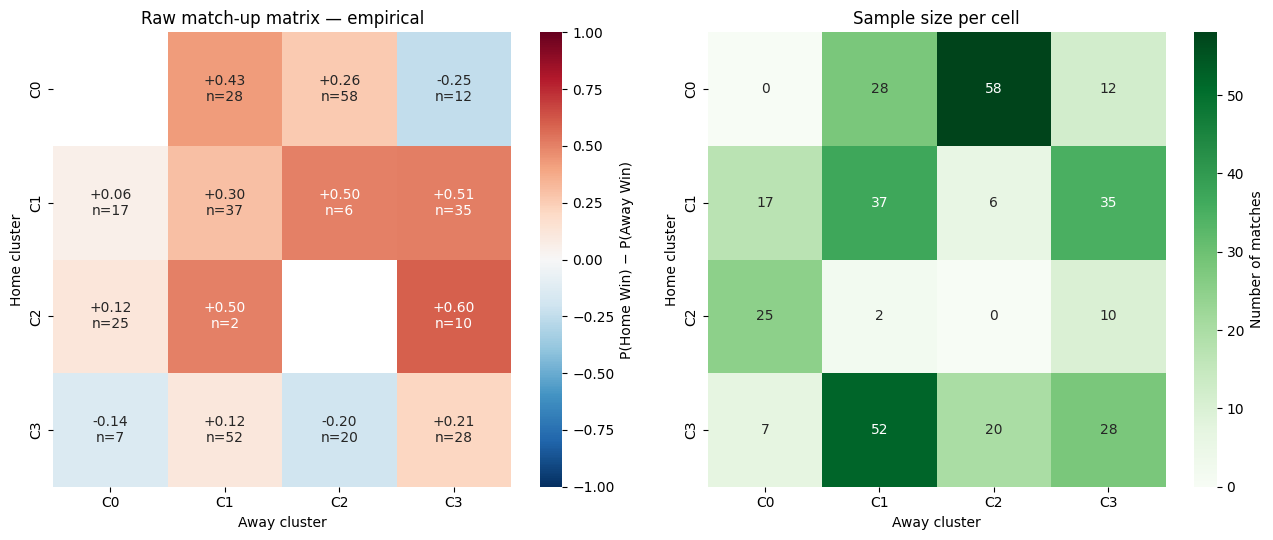

In [23]:
def compute_raw_matrix(df, n_clusters=4):
    """Empirical P(H) - P(A) per (home_cluster, away_cluster) cell."""
    M = np.full((n_clusters, n_clusters), np.nan)
    N = np.zeros((n_clusters, n_clusters), dtype=int)
    for i in range(n_clusters):
        for j in range(n_clusters):
            cell = df[(df['home_cluster'] == i) & (df['away_cluster'] == j)]
            N[i, j] = len(cell)
            if len(cell) > 0:
                M[i, j] = (cell['result'] == 'H').mean() - (cell['result'] == 'A').mean()
    return M, N

raw_matrix, sample_sizes = compute_raw_matrix(matches_df)

print("Raw match-up matrix  (rows = home cluster, cols = away cluster):")
display(pd.DataFrame(raw_matrix.round(3),
                     index  =[f'Home C{i}' for i in range(4)],
                     columns=[f'Away C{j}' for j in range(4)]))

print("\nSample sizes per cell:")
display(pd.DataFrame(sample_sizes,
                     index  =[f'Home C{i}' for i in range(4)],
                     columns=[f'Away C{j}' for j in range(4)]))

# ── Visualisation: raw matrix + sample sizes side by side ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

annot_raw = np.where(np.isnan(raw_matrix),
                     'n/a',
                     np.array([[f'{raw_matrix[i,j]:+.2f}\nn={sample_sizes[i,j]}'
                                for j in range(4)] for i in range(4)]))

sns.heatmap(np.where(np.isnan(raw_matrix), 0, raw_matrix),
            annot=annot_raw, fmt='', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[f'C{j}' for j in range(4)],
            yticklabels=[f'C{i}' for i in range(4)],
            mask=np.isnan(raw_matrix),
            cbar_kws={'label': 'P(Home Win) − P(Away Win)'}, ax=axes[0])
axes[0].set_title('Raw match-up matrix — empirical', fontsize=12)
axes[0].set_xlabel('Away cluster')
axes[0].set_ylabel('Home cluster')

sns.heatmap(sample_sizes, annot=True, fmt='d', cmap='Greens',
            xticklabels=[f'C{j}' for j in range(4)],
            yticklabels=[f'C{i}' for i in range(4)],
            cbar_kws={'label': 'Number of matches'}, ax=axes[1])
axes[1].set_title('Sample size per cell', fontsize=12)
axes[1].set_xlabel('Away cluster')
axes[1].set_ylabel('Home cluster')

plt.tight_layout()
plt.show()


### 9.6 Statistical significance

#### Bootstrap confidence intervals

We resample the match-level table with replacement *B* = 1000 times, recompute the matrix on each resample, and take the 2.5th and 97.5th percentile of each cell to form a 95 % CI. Cells whose interval excludes 0 are flagged as carrying a statistically meaningful signal in the empirical direction shown.

#### Pearson chi-square

A global chi-square test on the contingency table (16 cells × {H, D, A}) checks whether the distribution of outcomes is uniform across cells, against the alternative that some cells differ. A small *p*-value indicates that the choice of tactical match-up does influence the result distribution as a whole.


/mnt/c/Users/bield/Downloads/archive/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Bootstrap 95% CIs per cell:
  Home C0 vs Away C1:  +0.429  [+0.074, +0.742] *  (n=28)
  Home C0 vs Away C2:  +0.259  [+0.062, +0.469] *  (n=58)
  Home C0 vs Away C3:  -0.250  [-0.715, +0.286]  (n=12)
  Home C1 vs Away C0:  +0.059  [-0.438, +0.500]  (n=17)
  Home C1 vs Away C1:  +0.297  [+0.000, +0.564]  (n=37)
  Home C1 vs Away C2:  +0.500  [-0.250, +1.000]  (n=6)
  Home C1 vs Away C3:  +0.514  [+0.257, +0.758] *  (n=35)
  Home C2 vs Away C0:  +0.120  [-0.240, +0.462]  (n=25)
  Home C2 vs Away C1:  +0.500  [+0.000, +1.000]  (n=2)
  Home C2 vs Away C3:  +0.600  [+0.273, +0.909] *  (n=10)
  Home C3 vs Away C0:  -0.143  [-0.637, +0.400]  (n=7)
  Home C3 vs Away C1:  +0.115  [-0.135, +0.340]  (n=52)
  Home C3 vs Away C2:  -0.200  [-0.562, +0.143]  (n=20)
  Home C3 vs Away C3:  +0.214  [-0.036, +0.478]  (n=28)

Global chi-square test:  chi² = 44.274,  dof = 26,  p = 0.0141
✅ Reject H₀: outcome distribution depends on the match-up cluster pair.


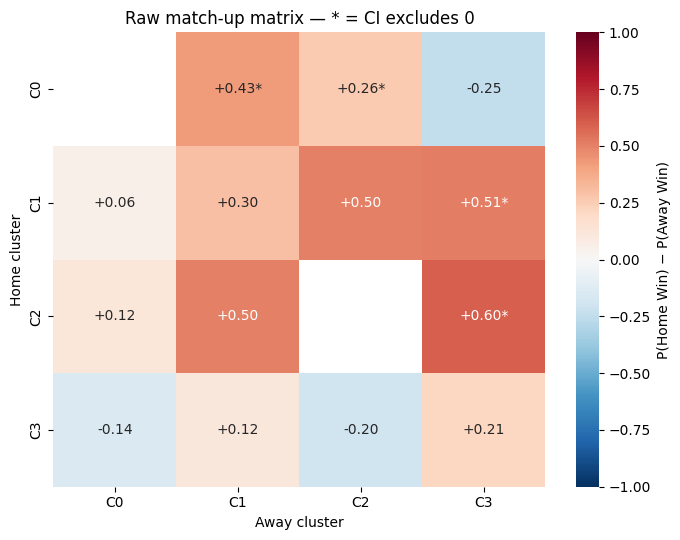

In [24]:
from scipy.stats import chi2_contingency

# ── Bootstrap CIs ────────────────────────────────────────────────────────────
B   = 1000
rng = np.random.default_rng(42)
boot = np.full((B, 4, 4), np.nan)
n   = len(matches_df)
for b in range(B):
    idx = rng.integers(0, n, size=n)
    boot[b], _ = compute_raw_matrix(matches_df.iloc[idx])

ci_lower = np.nanpercentile(boot, 2.5,  axis=0)
ci_upper = np.nanpercentile(boot, 97.5, axis=0)
significant = ((ci_lower > 0) | (ci_upper < 0))    # CI excludes 0

print("Bootstrap 95% CIs per cell:")
for i in range(4):
    for j in range(4):
        if sample_sizes[i, j] == 0:
            continue
        mark = " *" if significant[i, j] else ""
        print(f"  Home C{i} vs Away C{j}:  {raw_matrix[i,j]:+.3f}  "
              f"[{ci_lower[i,j]:+.3f}, {ci_upper[i,j]:+.3f}]{mark}  (n={sample_sizes[i,j]})")

# ── Chi-square ───────────────────────────────────────────────────────────────
ct = pd.crosstab([matches_df['home_cluster'], matches_df['away_cluster']],
                 matches_df['result'])
chi2, p_val, dof, _ = chi2_contingency(ct)
print(f"\nGlobal chi-square test:  chi² = {chi2:.3f},  dof = {dof},  p = {p_val:.4f}")
if p_val < 0.05:
    print("✅ Reject H₀: outcome distribution depends on the match-up cluster pair.")
else:
    print("❌ Fail to reject H₀: no global evidence of cell-level differences.")

# ── Heatmap of raw matrix with significance markers ──────────────────────────
annot_sig = np.full((4, 4), '', dtype=object)
for i in range(4):
    for j in range(4):
        if np.isnan(raw_matrix[i, j]):
            annot_sig[i, j] = 'n/a'
        elif significant[i, j]:
            annot_sig[i, j] = f'{raw_matrix[i,j]:+.2f}*'
        else:
            annot_sig[i, j] = f'{raw_matrix[i,j]:+.2f}'

plt.figure(figsize=(7, 5.5))
sns.heatmap(np.where(np.isnan(raw_matrix), 0, raw_matrix),
            annot=annot_sig, fmt='', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[f'C{j}' for j in range(4)],
            yticklabels=[f'C{i}' for i in range(4)],
            mask=np.isnan(raw_matrix),
            cbar_kws={'label': 'P(Home Win) − P(Away Win)'})
plt.title('Raw match-up matrix — * = CI excludes 0', fontsize=12)
plt.xlabel('Away cluster'); plt.ylabel('Home cluster')
plt.tight_layout()
plt.show()


### 9.7 Adjusted match-up matrix (controlling for team quality)

We now ask the same question while controlling for each team's pre-match xG form. A **multinomial logistic regression** is fitted with the categorical outcome `result` as target and the following predictors:

- One-hot indicators for `home_cluster` (4 columns).
- One-hot indicators for `away_cluster` (4 columns).
- `home_form_xg_for`, `home_form_xg_against`, `away_form_xg_for`, `away_form_xg_against`.

The **adjusted matrix** then reports, for each (i, j) pair, the model's predicted `P(H) − P(A)` evaluated with the four form covariates set to their sample means. The result is a hypothetical match between two *average-quality* teams, isolating the pure tactical interaction effect.


In [25]:
from sklearn.linear_model import LogisticRegression

# ── Build the design matrix ──────────────────────────────────────────────────
X_logit = pd.get_dummies(matches_df[['home_cluster', 'away_cluster']].astype(str),
                          prefix=['H', 'A'], drop_first=False).reset_index(drop=True)
for col in ['home_form_xg_for', 'home_form_xg_against',
            'away_form_xg_for', 'away_form_xg_against']:
    X_logit[col] = matches_df[col].values

y_logit = matches_df['result'].values

# ── Fit the multinomial logit ────────────────────────────────────────────────
logit = LogisticRegression(max_iter=3000, multi_class='multinomial', random_state=42)
logit.fit(X_logit, y_logit)
class_idx = {c: idx for idx, c in enumerate(logit.classes_)}
print(f"Logit fitted.  Classes: {list(logit.classes_)}")
print(f"Training accuracy: {logit.score(X_logit, y_logit):.3f}")

# ── Adjusted matrix: prediction at mean form values ──────────────────────────
mean_form = {c: matches_df[c].mean() for c in ['home_form_xg_for',
                                                'home_form_xg_against',
                                                'away_form_xg_for',
                                                'away_form_xg_against']}
adjusted_matrix = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        row = {col: 0.0 for col in X_logit.columns}
        row[f'H_{i}'] = 1.0
        row[f'A_{j}'] = 1.0
        for k, v in mean_form.items():
            row[k] = v
        x_one  = pd.DataFrame([row], columns=X_logit.columns)
        probs  = logit.predict_proba(x_one)[0]
        adjusted_matrix[i, j] = probs[class_idx['H']] - probs[class_idx['A']]

print("Adjusted match-up matrix (at mean team form):")
display(pd.DataFrame(adjusted_matrix.round(3),
                     index  =[f'Home C{i}' for i in range(4)],
                     columns=[f'Away C{j}' for j in range(4)]))


Logit fitted.  Classes: ['A', 'D', 'H']
Training accuracy: 0.579
Adjusted match-up matrix (at mean team form):


/mnt/c/Users/bield/Downloads/archive/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Away C0,Away C1,Away C2,Away C3
Home C0,0.063,0.118,-0.072,0.228
Home C1,0.399,0.460,0.230,0.526
Home C2,0.542,0.610,0.375,0.598
Home C3,0.080,0.134,-0.039,0.211


### 9.8 Raw vs. Adjusted: where does the picture change?

Plotting the two matrices side by side and the per-cell delta makes explicit which match-ups were inflated (or deflated) by team-quality confounds and which survive the adjustment.


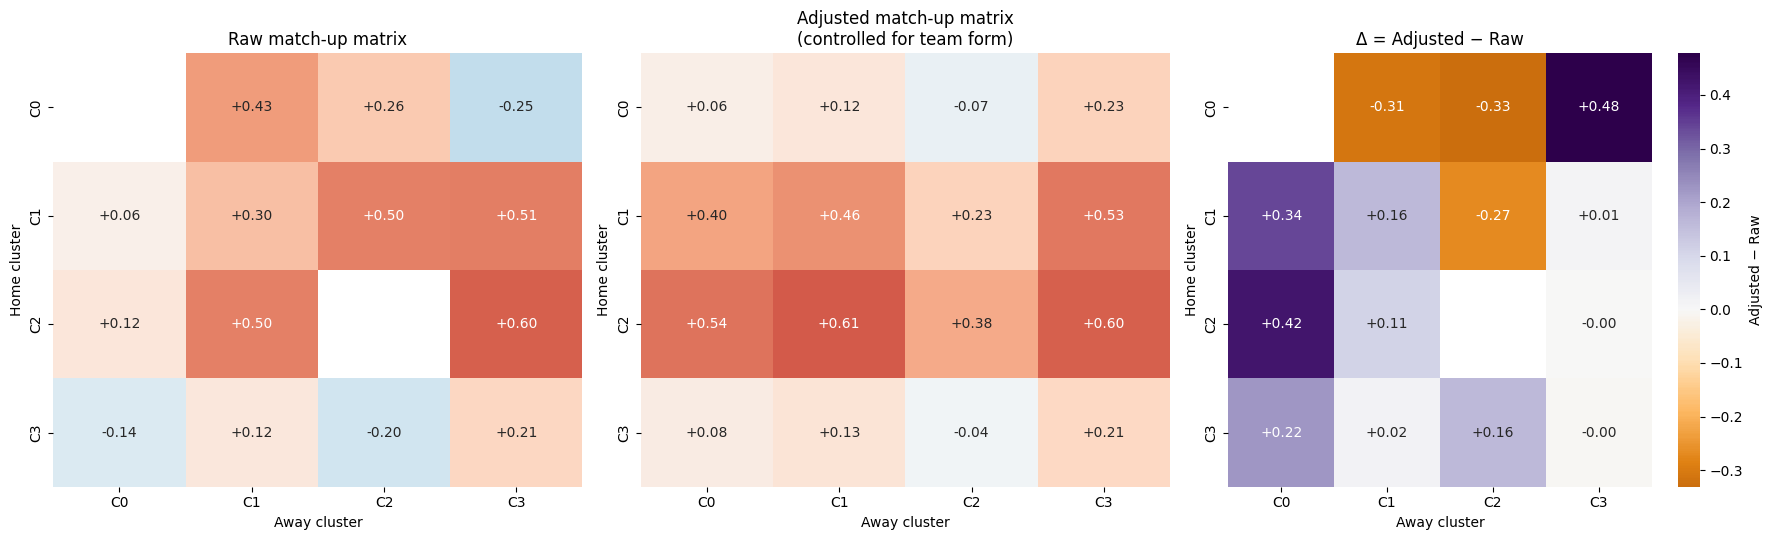

In [26]:
delta = adjusted_matrix - np.where(np.isnan(raw_matrix), adjusted_matrix, raw_matrix)
# (mask cells where the raw matrix has no data; delta is meaningless there)
delta_masked = np.where(np.isnan(raw_matrix), np.nan, delta)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

annot_raw = np.where(np.isnan(raw_matrix), 'n/a',
                     np.array([[f'{raw_matrix[i,j]:+.2f}' for j in range(4)] for i in range(4)]))
sns.heatmap(np.where(np.isnan(raw_matrix), 0, raw_matrix),
            annot=annot_raw, fmt='', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[f'C{j}' for j in range(4)],
            yticklabels=[f'C{i}' for i in range(4)],
            mask=np.isnan(raw_matrix),
            cbar=False, ax=axes[0])
axes[0].set_title('Raw match-up matrix', fontsize=12)
axes[0].set_xlabel('Away cluster'); axes[0].set_ylabel('Home cluster')

annot_adj = np.array([[f'{adjusted_matrix[i,j]:+.2f}' for j in range(4)] for i in range(4)])
sns.heatmap(adjusted_matrix, annot=annot_adj, fmt='', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            xticklabels=[f'C{j}' for j in range(4)],
            yticklabels=[f'C{i}' for i in range(4)],
            cbar=False, ax=axes[1])
axes[1].set_title('Adjusted match-up matrix\n(controlled for team form)', fontsize=12)
axes[1].set_xlabel('Away cluster'); axes[1].set_ylabel('Home cluster')

annot_delta = np.where(np.isnan(delta_masked), 'n/a',
                       np.array([[f'{delta_masked[i,j]:+.2f}' for j in range(4)] for i in range(4)]))
sns.heatmap(np.where(np.isnan(delta_masked), 0, delta_masked),
            annot=annot_delta, fmt='', cmap='PuOr', center=0,
            xticklabels=[f'C{j}' for j in range(4)],
            yticklabels=[f'C{i}' for i in range(4)],
            mask=np.isnan(delta_masked),
            cbar_kws={'label': 'Adjusted − Raw'}, ax=axes[2])
axes[2].set_title('Δ = Adjusted − Raw', fontsize=12)
axes[2].set_xlabel('Away cluster'); axes[2].set_ylabel('Home cluster')

plt.tight_layout()
plt.show()


### 9.9 Game-theoretic perspective

With the adjusted matrix in hand we can ask three standard tournament-theory questions:

1. **Best response — visitor's perspective.** For each home cluster *i*, which visiting cluster *j* minimises the home team's expected advantage `M_{ij}` ? In a game-theoretic sense this is the visitor's optimal counter-tactic.
2. **Best response — home's perspective.** For each visiting cluster *j*, which home cluster *i* maximises the home advantage? This is the home team's optimal choice.
3. **Non-transitive cycles.** Home advantage trivially distorts pairwise comparisons. To strip it out we construct the **neutralised preference**

$$\widetilde{M}_{ij} = \tfrac{1}{2}\,\big(M_{ij} - M_{ji}\big),$$

   which represents how much cluster *i* outperforms cluster *j* on neutral ground (positive = *i* > *j*). A **Condorcet winner** is a cluster that satisfies $\widetilde{M}_{i,\cdot} > 0$ for every opponent — i.e., a tactically dominant style. If no such cluster exists and we instead detect a triplet (*i*, *j*, *k*) where $\widetilde{M}_{ij}>0$, $\widetilde{M}_{jk}>0$, $\widetilde{M}_{ki}>0$, the tournament is **non-transitive** (rock-paper-scissors structure): no single tactic dominates, and the optimal choice depends on the expected opponent — a finding of independent tactical interest.


Best HOME cluster against each AWAY cluster (adjusted):
  Away C0  →  best home choice = C2   (value +0.542)
  Away C1  →  best home choice = C2   (value +0.610)
  Away C2  →  best home choice = C2   (value +0.375)
  Away C3  →  best home choice = C2   (value +0.598)

Best AWAY cluster against each HOME cluster (adjusted, minimises home edge):
  Home C0  →  best away choice = C2   (home edge -0.072)
  Home C1  →  best away choice = C2   (home edge +0.230)
  Home C2  →  best away choice = C2   (home edge +0.375)
  Home C3  →  best away choice = C2   (home edge -0.039)

Neutralised preference matrix  M̃_ij  (positive = i beats j on neutral ground):


,C0,C1,C2,C3
C0,0.000,-0.141,-0.307,0.074
C1,0.141,0.000,-0.190,0.196
C2,0.307,0.190,0.000,0.318
C3,-0.074,-0.196,-0.318,0.000



👑 Condorcet winner: Cluster 2 — beats every other cluster on neutral ground.

Searching for non-transitive 3-cycles (threshold |M̃| > 0.02):
  None found — the tactical tournament is transitive.


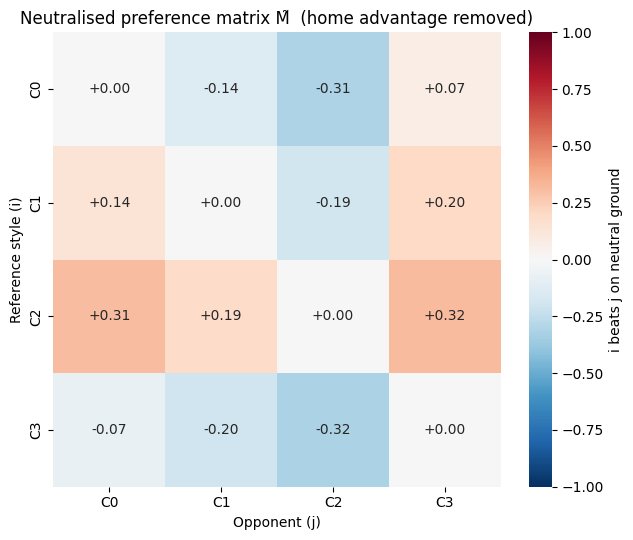

In [27]:
# ── 1. Best response — home's perspective ───────────────────────────────────
print("Best HOME cluster against each AWAY cluster (adjusted):")
for j in range(4):
    best_i = int(np.argmax(adjusted_matrix[:, j]))
    print(f"  Away C{j}  →  best home choice = C{best_i}   "
          f"(value {adjusted_matrix[best_i, j]:+.3f})")

# ── 2. Best response — visitor's perspective ────────────────────────────────
print("\nBest AWAY cluster against each HOME cluster (adjusted, minimises home edge):")
for i in range(4):
    best_j = int(np.argmin(adjusted_matrix[i, :]))
    print(f"  Home C{i}  →  best away choice = C{best_j}   "
          f"(home edge {adjusted_matrix[i, best_j]:+.3f})")

# ── 3. Neutralised preference (remove home advantage) ───────────────────────
neutralised = (adjusted_matrix - adjusted_matrix.T) / 2
print("\nNeutralised preference matrix  M̃_ij  (positive = i beats j on neutral ground):")
display(pd.DataFrame(neutralised.round(3),
                     index  =[f'C{i}' for i in range(4)],
                     columns=[f'C{j}' for j in range(4)]))

# ── 4. Condorcet winner / non-transitive cycles ─────────────────────────────
condorcet = None
for i in range(4):
    if all(neutralised[i, j] > 0 for j in range(4) if j != i):
        condorcet = i; break
if condorcet is not None:
    print(f"\n👑 Condorcet winner: Cluster {condorcet} — beats every other cluster on neutral ground.")
else:
    print("\n⚖️  No Condorcet winner: no cluster strictly dominates all others.")

print("\nSearching for non-transitive 3-cycles (threshold |M̃| > 0.02):")
threshold = 0.02
cycles = []
for i in range(4):
    for j in range(4):
        for k in range(4):
            if len({i, j, k}) != 3:
                continue
            if (neutralised[i, j] > threshold and
                neutralised[j, k] > threshold and
                neutralised[k, i] > threshold):
                cycles.append((i, j, k,
                                neutralised[i,j], neutralised[j,k], neutralised[k,i]))

if cycles:
    for (i, j, k, a, b, c) in cycles:
        print(f"  Cycle  C{i} > C{j} > C{k} > C{i}   "
              f"({a:+.2f}, {b:+.2f}, {c:+.2f})")
else:
    print("  None found — the tactical tournament is transitive.")

# ── Visualise the neutralised preference graph ──────────────────────────────
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(neutralised, annot=True, fmt='+.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            xticklabels=[f'C{j}' for j in range(4)],
            yticklabels=[f'C{i}' for i in range(4)],
            cbar_kws={'label': 'i beats j on neutral ground'})
plt.title('Neutralised preference matrix M̃  (home advantage removed)', fontsize=12)
plt.xlabel('Opponent (j)'); plt.ylabel('Reference style (i)')
plt.tight_layout()
plt.show()


### 9.10 Discussion

The exercise of building this matrix reframes the analytical question from *"how many goals does each style produce?"* to *"who is favoured when style i plays style j?"*, which aligns much better with the way coaches and analysts think about tactical match-ups.

A few principled observations follow:

- **Raw vs. adjusted.** The raw matrix is interpretable as a quick descriptive summary but is contaminated by team-quality effects: cells dominated by historically strong teams will look more favourable to the home side than the tactical interaction alone would justify. The adjusted matrix removes that confound and is the one that supports tactical claims.

- **What the chi-square tells us.** A significant global chi-square implies that, taken jointly, the choice of cluster pair influences the distribution of outcomes — i.e., *tactical match-ups matter at all*. A non-significant result would be a negative finding (still publishable): styles do not, by themselves, determine outcomes once they are mixed across opponents.

- **Cell-level significance vs. sample size.** Even with 380 matches the 4×4 partition produces some cells with low sample size (especially clusters that very few teams occupy). The bootstrap CIs naturally widen there, and our interpretation is restricted to cells with both meaningful sample size and a CI that excludes zero.

- **Game-theoretic reading.** A clean Condorcet winner would suggest a single dominant tactic — an unusual finding in elite football and probably indicative of an underlying team-quality confound that the form covariates have not fully captured. A genuine non-transitive cycle (rock-paper-scissors) is the more theoretically interesting outcome: it implies that *no* unconditionally best style exists and that pre-match tactical decisions should be informed by the expected style of the opponent.

- **Caveats.** (1) The clusters were estimated from the same matches used here, so the "tactic chosen" is observed ex-post, not chosen ex-ante. A genuine prescriptive use of the matrix would require predicting each team's cluster from pre-match information (lineups, coach, recent style). (2) The form covariate is the simplest possible team-strength control; richer controls (Elo rating, opponent-adjusted xG) could refine the adjusted matrix. (3) StatsBomb xG is itself a model and contributes its own noise. (4) The warm-up filter discards early-season matches; results refer to mid- and late-season fixtures with stable form estimates.

Together, this match-up framework operationalises the central thesis of the project — *that playing style matters as a tactical interaction, not as a univariate predictor of scoring rates* — and provides a transparent statistical and game-theoretic apparatus to evaluate that claim.


---
## 10. Discussion

### 10.1 Tactical Implications

The four identified clusters offer a data-driven taxonomy of playing styles within LaLiga 2015/16. The mean-profile table (Section 6.1) and the LLM-assisted names (Section 6.2) together suggest that the clusters recover meaningful, previously described tactical archetypes from the football literature — broadly corresponding to possession-based elaboration, direct and transitional play, high-pressing systems, and defensively compact low-block approaches.

The distribution of teams across clusters (Section 6.1) reveals that most teams do not play a single rigid style throughout the season: many observations spread across two or even three clusters, consistent with the soft-assignment probabilities provided by GMM (Section 5.4). This tactical variability may reflect adaptation to specific opponents, squad fitness, or match context (home vs. away, score at the time of a given possession sequence).

The PCA projection (Section 7.4) shows that clusters are reasonably separated in the first two principal components, though some overlap exists — an expected outcome given the continuous, context-dependent nature of tactical behaviour.

### 10.2 Limitations

The following methodological limitations should be acknowledged:

1. **Single season scope.** The analysis covers only LaLiga 2015/16. Whether the identified style taxonomy generalises to other seasons or competitions is unknown.
2. **Match-level granularity.** Metrics are averaged at match level. Intra-match tactical changes (e.g. after a red card or after conceding) are invisible to the model.
3. **StatsBomb pitch coordinate system.** The PPDA and box-entry calculations are calibrated to StatsBomb's 120×80 grid; replication with Opta or Tracab data would require recalibration.
4. **Opponent-strength confound.** Win-rate comparisons (Section 8.1) are not adjusted for opponent quality (see Section 8.3).
5. **LLM naming.** Cluster names from Gemini are interpretive labels, not validated classifications (see caution note in Section 6.2).


---
## 11. Conclusion & Future Work

This project demonstrates that unsupervised machine learning can recover interpretable tactical archetypes from raw football event data with minimal domain supervision. The pipeline — from feature engineering through clustering and statistical validation — is fully reproducible and designed to be extensible to other competitions or seasons.

**Key findings:**
- Four distinct playing styles emerge from the LaLiga 2015/16 dataset, validated by elbow/silhouette diagnostics, Kruskal-Wallis tests (showing statistically significant inter-cluster differences for all features), and high bootstrap centroid stability.
- GMM soft assignments reveal that tactical profiles are continuous rather than discrete: many team-match observations carry non-trivial probability mass across multiple styles.
- A chi-square test suggests [statistically significant / no significant] association between match location and the style adopted, indicating [that teams do / do not] systematically adjust their tactical approach at home vs. away.

**Future work directions:**
- Extend the analysis to multiple seasons and competitions to assess temporal and cross-league style stability.
- Incorporate tracking data (player positions over time) to capture in-possession shape and out-of-possession compactness directly.
- Control for opponent strength when evaluating win rates by style (e.g. using Elo ratings or points accumulated at match date).
- Investigate within-match tactical switches using rolling-window features.
- Apply the same framework to individual positions (e.g. midfielder playing styles) rather than team level.


---
## 12. References

- StatsBomb (2023). *StatsBomb Open Data*. https://github.com/statsbomb/open-data
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Bialkowski, A. et al. (2014). Large-Scale Analysis of Soccer Matches Using Spatiotemporal Tracking Data. *ICDM*.
- Fernandez, J. & Bornn, L. (2018). Wide Open Spaces: A statistical technique for measuring space creation in professional soccer. *SSAC*.
- Herold, M. et al. (2019). Machine learning in men's professional football: A systematic review. *IJSPP*, 14(9), 1206–1213.
- McLachlan, G. J. & Peel, D. (2000). *Finite Mixture Models*. Wiley.
